# TFT Forecaster — Final

v2.1 config with Optuna-optimized hyperparameters hard-coded.
Features: calendar events, `days_after_christmas`, state identifier.
Christmas = 0 post-prediction.

**Run cells top-to-bottom. Training time: ~8-10 min on RTX 5080.**

In [1]:
# Cell 1: Imports & GPU check
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import MAE

pl.seed_everything(42, workers=True)
print(f'PyTorch : {torch.__version__}')
print(f'Lightning: {pl.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  Device : {torch.cuda.get_device_name(0)}')
    torch.set_float32_matmul_precision('medium')
else:
    print('No GPU detected.')

Seed set to 42


PyTorch : 2.9.1+cu130
Lightning: 2.6.5
CUDA     : True
  Device : NVIDIA GeForce RTX 5080


## 1. Data Preparation

In [2]:
# Cell 2: Data prep
TRAIN_PATH  = 'train.csv'
EVENTS_PATH = 'calendar_events.csv'
train  = pd.read_csv(TRAIN_PATH, parse_dates=['date'])
events = pd.read_csv(EVENTS_PATH, parse_dates=['date'])
FORECAST_START = pd.Timestamp('2015-10-01')
FORECAST_END   = pd.Timestamp('2015-12-31')
HORIZON = (FORECAST_END - FORECAST_START).days + 1
print(f'Horizon: {HORIZON} days')

events['event'] = events['event'].str.split(',').str[0].str.strip()
events_map = dict(zip(events['date'], events['event']))
STATE_MAP = {'0':'ALL','1':'CA','2':'CA','3':'CA','4':'CA','5':'TX','6':'TX','7':'TX','8':'WI','9':'WI','10':'WI'}
CHRISTMAS_2015 = pd.Timestamp('2015-12-25')

date_min  = train['date'].min()
all_dates = pd.date_range(date_min, FORECAST_END, freq='D')
all_stores = sorted(train['store_id'].unique())
grid = pd.MultiIndex.from_product([all_stores, all_dates], names=['store_id','date']).to_frame(index=False)
df = grid.merge(train[['store_id','date','revenue']], on=['store_id','date'], how='left')

df['dow']        = df['date'].dt.dayofweek.astype(str)
df['month']      = df['date'].dt.month.astype(str)
df['day']        = df['date'].dt.day.astype(np.float32)
df['week']       = df['date'].dt.isocalendar().week.astype(np.float32)
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(np.float32)
df['event']      = df['date'].map(events_map).fillna('none').astype(str)
df['is_event']   = (df['event'] != 'none').astype(np.float32)

def days_to_holiday(date_series, hm, hd):
    years = date_series.dt.year
    holidays = pd.to_datetime(years.astype(str) + f'-{hm:02d}-{hd:02d}', errors='coerce')
    return (holidays - date_series).dt.days.astype(np.float32).clip(lower=-30, upper=60)

df['days_to_christmas']    = days_to_holiday(df['date'], 12, 25)
df['days_to_thanksgiving'] = days_to_holiday(df['date'], 11, 25)

# Days AFTER Christmas (post-holiday recovery)
def days_after_christmas(date_series):
    years = date_series.dt.year
    christmas = pd.to_datetime(years.astype(str) + '-12-25', errors='coerce')
    delta = (date_series - christmas).dt.days.astype(np.float32)
    prior = pd.to_datetime((years - 1).astype(str) + '-12-25', errors='coerce')
    delta_prior = (date_series - prior).dt.days.astype(np.float32)
    result = np.where(delta >= 0, delta, delta_prior)
    return np.clip(result, 0, 30).astype(np.float32)

df['days_after_christmas'] = days_after_christmas(df['date'])

df['time_idx'] = (df['date'] - date_min).dt.days.astype(np.int64)
df['store_id'] = df['store_id'].astype(str)
df['state']    = df['store_id'].map(STATE_MAP)

mask_past = df['date'] < FORECAST_START
df.loc[mask_past, 'revenue'] = df.loc[mask_past].groupby('store_id')['revenue'].transform(lambda s: s.ffill().bfill())
df['revenue'] = df['revenue'].fillna(0.0).astype(np.float32)

# Remove store 0 (All Stores) from training — compute it by summing stores 1-10 after prediction
df_train = df[df['store_id'] != '0'].copy()
print(f'Grid (training, no store 0): {len(df_train):,} rows')

Horizon: 92 days
Grid (training, no store 0): 17,980 rows


## 2. Build TimeSeriesDataSet

In [3]:
# Cell 3: Dataset
MAX_ENCODER_LENGTH    = 180
MAX_PREDICTION_LENGTH = HORIZON
training_cutoff = int(df.loc[df['date'] == FORECAST_START - pd.Timedelta(days=1), 'time_idx'].iloc[0])

training = TimeSeriesDataSet(
    df_train[df_train['time_idx'] <= training_cutoff],
    time_idx='time_idx', target='revenue', group_ids=['store_id'],
    max_encoder_length=MAX_ENCODER_LENGTH, min_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH, min_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=['store_id', 'state'],
    time_varying_known_categoricals=['event', 'dow', 'month'],
    time_varying_known_reals=['time_idx','is_event','is_weekend','day','week',
                              'days_to_christmas','days_to_thanksgiving','days_after_christmas'],
    time_varying_unknown_reals=['revenue'],
    target_normalizer=GroupNormalizer(groups=['store_id'], transformation='softplus'),
    categorical_encoders={'event':NaNLabelEncoder(add_nan=True),'dow':NaNLabelEncoder(add_nan=True),
                          'month':NaNLabelEncoder(add_nan=True),'state':NaNLabelEncoder(add_nan=True)},
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
    allow_missing_timesteps=False,
)
validation = TimeSeriesDataSet.from_dataset(training, df_train, predict=True, stop_randomization=True)

BATCH_SIZE = 128
train_dataloader = training.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_dataloader   = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
print(f'Training samples: {len(training):,}')

Training samples: 14,350


## 3. Train TFT

Optuna-optimized hyperparameters (from prior search):
- `learning_rate = 0.000611`
- `hidden_size = 96`
- `dropout = 0.25`
- `attention_head_size = 4`

In [4]:
# Cell 4: Train with best known hyperparameters
early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=8, mode='min')
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(
    max_epochs=30, accelerator='auto', devices=1,
    gradient_clip_val=0.1, callbacks=[early_stop, lr_monitor],
    enable_progress_bar=True, log_every_n_steps=20,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.000611,
    hidden_size=96,
    attention_head_size=4,
    dropout=0.25,
    hidden_continuous_size=32,
    output_size=1,
    loss=MAE(),
    log_interval=20,
    reduce_on_plateau_patience=3,
)
print(f'TFT parameters: {sum(p.numel() for p in tft.parameters()):,}')

trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TFT parameters: 675,156


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    555 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    832 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 28.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 97.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 87.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 74.5 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 74.5 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 18.6 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    192 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 46.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 23.3 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 18.8 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 37.4 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 18.8 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     97 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 675 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 675 K                                                                                                
Total estimated model params size (MB): 2.701                                                                      
Modules in train mode: 519                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

## 4. Predict

In [5]:
# Cell 5: Predict
best_ckpt = trainer.checkpoint_callback.best_model_path if trainer.checkpoint_callback else ''
if best_ckpt:
    print(f'Loading: {best_ckpt}')
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
else:
    best_tft = tft

out = best_tft.predict(val_dataloader, mode='prediction', return_x=True, return_index=True)
preds = out.output.cpu().numpy()
if preds.ndim == 3: preds = preds.squeeze(-1)
index = out.index.reset_index(drop=True)
print(f'Predictions shape: {preds.shape}')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loading: C:\Users\Guy\Documents\M.S. MLDS\Advanced ML\FinalProject\AdvancedML_Project\DeepLearning\lightning_logs\version_75\checkpoints\epoch=8-step=1008.ckpt
Predictions shape: (10, 92)


## 5. Bias Calibration (2014 validation)

Run inference on Oct 1 – Dec 31, 2014 (same shape as forecast).
Compute per-store, per-day-of-horizon scale factor: `actual / predicted`.
Apply to 2015 predictions.

In [6]:
# Cell 5b: Calibration — predict 2014 Q4, compute bias scale per store per day

# 2014 calibration window (same shape: Oct 1 - Dec 31)
CALIB_START = pd.Timestamp('2014-10-01')
CALIB_END   = pd.Timestamp('2014-12-31')
calib_cutoff = int(df.loc[df['date'] == CALIB_START - pd.Timedelta(days=1), 'time_idx'].iloc[0])

# Build calibration dataset using the same training dataset structure
# We need data up to the calib_cutoff, then predict the 92-day window
calib_training = TimeSeriesDataSet(
    df_train[df_train['time_idx'] <= calib_cutoff],
    time_idx='time_idx', target='revenue', group_ids=['store_id'],
    max_encoder_length=MAX_ENCODER_LENGTH, min_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH, min_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=['store_id', 'state'],
    time_varying_known_categoricals=['event', 'dow', 'month'],
    time_varying_known_reals=['time_idx','is_event','is_weekend','day','week',
                              'days_to_christmas','days_to_thanksgiving','days_after_christmas'],
    time_varying_unknown_reals=['revenue'],
    target_normalizer=GroupNormalizer(groups=['store_id'], transformation='softplus'),
    categorical_encoders={'event':NaNLabelEncoder(add_nan=True),'dow':NaNLabelEncoder(add_nan=True),
                          'month':NaNLabelEncoder(add_nan=True),'state':NaNLabelEncoder(add_nan=True)},
    add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
    allow_missing_timesteps=False,
)

# Validation = predict mode pinned to calib window
calib_validation = TimeSeriesDataSet.from_dataset(calib_training, df_train, predict=True, stop_randomization=True)
calib_dl = calib_validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

# Run inference on 2014 Q4
calib_out = best_tft.predict(calib_dl, mode='prediction', return_x=True, return_index=True)
calib_preds = calib_out.output.cpu().numpy()
if calib_preds.ndim == 3: calib_preds = calib_preds.squeeze(-1)
calib_index = calib_out.index.reset_index(drop=True)

# Build 2014 predictions DataFrame
calib_records = []
for i, row in calib_index.iterrows():
    store_id = row['store_id']
    start_idx = int(row['time_idx'])
    for j in range(calib_preds.shape[1]):
        date = date_min + pd.Timedelta(days=start_idx + j)
        calib_records.append({'store_id': store_id, 'date': date, 'predicted': float(calib_preds[i, j]), 'day_offset': j})

calib_df = pd.DataFrame(calib_records)
calib_df['predicted'] = calib_df['predicted'].clip(lower=1.0)  # avoid division by zero

# Get actual 2014 Q4 revenue
actual_2014 = df_train[(df_train['date'] >= CALIB_START) & (df_train['date'] <= CALIB_END)][['store_id','date','revenue']].copy()

# Merge predictions with actuals
calib_merged = calib_df.merge(actual_2014, on=['store_id', 'date'], how='inner')

# Compute bias scale: actual / predicted (per store, per day_offset)
calib_merged['bias_scale'] = calib_merged['revenue'] / calib_merged['predicted']

# Extract the scale factor table: store_id x day_offset
bias_table = calib_merged.pivot_table(index='store_id', columns='day_offset', values='bias_scale', aggfunc='mean')

print(f'Bias calibration table shape: {bias_table.shape}')
print(f'Mean bias scale across all stores/days: {calib_merged["bias_scale"].mean():.4f}')
print('Per-store mean bias scale:')
print(calib_merged.groupby('store_id')['bias_scale'].mean())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Bias calibration table shape: (0, 0)
Mean bias scale across all stores/days: nan
Per-store mean bias scale:
Series([], Name: bias_scale, dtype: float64)


## 6. LightGBM Delta Correction

Train LightGBM on the residuals (actual - TFT_biased) from the full training history.
Then predict the correction delta for Oct-Dec 2015.

In [7]:
# Cell 5c: LightGBM delta correction layer
import lightgbm as lgb

# First: build submission_long with bias-corrected predictions for Oct-Dec 2015
records = []
for i, row in index.iterrows():
    store_id = row['store_id']
    start_idx = int(row['time_idx'])
    for j in range(preds.shape[1]):
        date = date_min + pd.Timedelta(days=start_idx + j)
        records.append({'store_id': store_id, 'date': date, 'prediction': float(preds[i, j])})

submission_long = pd.DataFrame(records)
submission_long['prediction'] = submission_long['prediction'].clip(lower=0)
submission_long.loc[submission_long['date'] == CHRISTMAS_2015, 'prediction'] = 0.0

# Apply bias calibration
submission_long['day_offset'] = (submission_long['date'] - FORECAST_START).dt.days
submission_long['prediction_biased'] = submission_long.apply(
    lambda row: row['prediction'] * bias_table.loc[row['store_id'], row['day_offset']]
    if row['store_id'] in bias_table.index and row['day_offset'] in bias_table.columns
    else row['prediction'], axis=1
)
submission_long['prediction_biased'] = submission_long['prediction_biased'].clip(lower=0)
submission_long.loc[submission_long['date'] == CHRISTMAS_2015, 'prediction_biased'] = 0.0
print(f'Bias-corrected predictions: {len(submission_long)} rows')

# Step 1: Run TFT inference on the full training period to get in-sample predictions
# We need to create overlapping prediction windows covering the training data
# For efficiency, we use the training dataset's predict mode on the full df_train

# Build a dataset that predicts starting from every valid position in training data
# We'll use a rolling approach: for each 92-day window where we have actuals,
# we need the TFT prediction. The simplest approach: run predict on all valid windows.

print('Running TFT inference on training history for delta computation...')

# Get all valid prediction windows from training data
# The validation dataset already gives us the last valid window (ending at training_cutoff)
# For the full training set, we use predict=False and gather all samples
full_train_dl = training.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

# Get predictions for all training samples
train_out = best_tft.predict(full_train_dl, mode='prediction', return_x=True, return_index=True)
train_preds = train_out.output.cpu().numpy()
if train_preds.ndim == 3: train_preds = train_preds.squeeze(-1)
train_index = train_out.index.reset_index(drop=True)

print(f'Training predictions shape: {train_preds.shape}')
print(f'Training index shape: {len(train_index)}')

# Step 2: Build training data for LightGBM
# For each prediction, compute delta = actual - predicted (bias-corrected)
train_records = []
for i, row in train_index.iterrows():
    store_id = row['store_id']
    start_idx = int(row['time_idx'])
    for j in range(train_preds.shape[1]):
        date = date_min + pd.Timedelta(days=start_idx + j)
        pred_val = float(train_preds[i, j])
        # Apply bias scale if available for this day offset and store
        if store_id in bias_table.index and j in bias_table.columns:
            pred_val *= bias_table.loc[store_id, j]
        train_records.append({
            'store_id': store_id, 'date': date,
            'tft_biased': max(pred_val, 0), 'day_offset': j
        })

train_delta_df = pd.DataFrame(train_records)

# Merge with actual revenue
actuals = df_train[['store_id', 'date', 'revenue']].copy()
train_delta_df = train_delta_df.merge(actuals, on=['store_id', 'date'], how='inner')

# Compute delta
train_delta_df['delta'] = train_delta_df['revenue'] - train_delta_df['tft_biased']

# Add features for LightGBM
train_delta_df['dow'] = train_delta_df['date'].dt.dayofweek
train_delta_df['month'] = train_delta_df['date'].dt.month
train_delta_df['day'] = train_delta_df['date'].dt.day
train_delta_df['week'] = train_delta_df['date'].dt.isocalendar().week.astype(int)
train_delta_df['is_weekend'] = (train_delta_df['dow'] >= 5).astype(int)
train_delta_df['store_num'] = train_delta_df['store_id'].astype(int)

# Merge calendar events
train_delta_df = train_delta_df.merge(
    df_train[['store_id','date','is_event','days_to_christmas','days_to_thanksgiving','days_after_christmas']].drop_duplicates(),
    on=['store_id','date'], how='left'
)

print(f'LightGBM training rows: {len(train_delta_df):,}')
print(f'Mean delta: {train_delta_df["delta"].mean():.2f}')

# Step 3: Train LightGBM
features = ['tft_biased', 'day_offset', 'dow', 'month', 'day', 'week',
            'is_weekend', 'store_num', 'is_event',
            'days_to_christmas', 'days_to_thanksgiving', 'days_after_christmas']

X_train_lgb = train_delta_df[features]
y_train_lgb = train_delta_df['delta']

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(X_train_lgb, y_train_lgb)
print('LightGBM trained successfully.')

# Step 4: Predict delta for Oct-Dec 2015 forecast
# Build features for the forecast period
forecast_lgb = submission_long[submission_long['store_id'] != '0'].copy()
forecast_lgb['tft_biased'] = forecast_lgb['prediction_biased']
forecast_lgb['day_offset'] = (forecast_lgb['date'] - FORECAST_START).dt.days
forecast_lgb['dow'] = forecast_lgb['date'].dt.dayofweek
forecast_lgb['month'] = forecast_lgb['date'].dt.month
forecast_lgb['day'] = forecast_lgb['date'].dt.day
forecast_lgb['week'] = forecast_lgb['date'].dt.isocalendar().week.astype(int)
forecast_lgb['is_weekend'] = (forecast_lgb['dow'] >= 5).astype(int)
forecast_lgb['store_num'] = forecast_lgb['store_id'].astype(int)

# Merge calendar features
forecast_lgb = forecast_lgb.merge(
    df_train[['store_id','date','is_event','days_to_christmas','days_to_thanksgiving','days_after_christmas']].drop_duplicates(),
    on=['store_id','date'], how='left'
)

X_forecast = forecast_lgb[features]
predicted_delta = lgb_model.predict(X_forecast)

# Step 5: Apply delta correction
forecast_lgb['prediction_final'] = (forecast_lgb['tft_biased'] + predicted_delta).clip(lower=0)

# Christmas = 0
forecast_lgb.loc[forecast_lgb['date'] == CHRISTMAS_2015, 'prediction_final'] = 0.0

print(f'Mean predicted delta: {predicted_delta.mean():.2f}')
print(f'LightGBM correction applied.')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Bias-corrected predictions: 920 rows
Running TFT inference on training history for delta computation...
Training predictions shape: (14350, 92)
Training index shape: 14350
LightGBM training rows: 1,320,200
Mean delta: -34.72
LightGBM trained successfully.
Mean predicted delta: -149.09
LightGBM correction applied.


## 7. Build Submission

In [8]:
# Cell 7: Build Submission using LightGBM-corrected predictions

# Use the LightGBM-corrected predictions as the final output
submission_final = forecast_lgb[['store_id','date','prediction_final']].copy()
submission_final = submission_final.rename(columns={'prediction_final': 'prediction'})

# Compute store 0 = sum of stores 1-10
store0_final = submission_final.groupby('date', as_index=False)['prediction'].sum()
store0_final['store_id'] = '0'
store0_final.loc[store0_final['date'] == CHRISTMAS_2015, 'prediction'] = 0.0

# Combine
submission_final = pd.concat([store0_final[['store_id','date','prediction']], submission_final], ignore_index=True)

# Build id column
submission_export = submission_final.copy()
submission_export['id'] = submission_export['store_id'].astype(str) + '_' + submission_export['date'].dt.strftime('%Y%m%d')
submission_export = submission_export[['id','prediction']].sort_values('id').reset_index(drop=True)
print(f'Final submission rows: {len(submission_export)} (including store 0 = sum of 1-10)')

Final submission rows: 1012 (including store 0 = sum of 1-10)


## 6. Plots

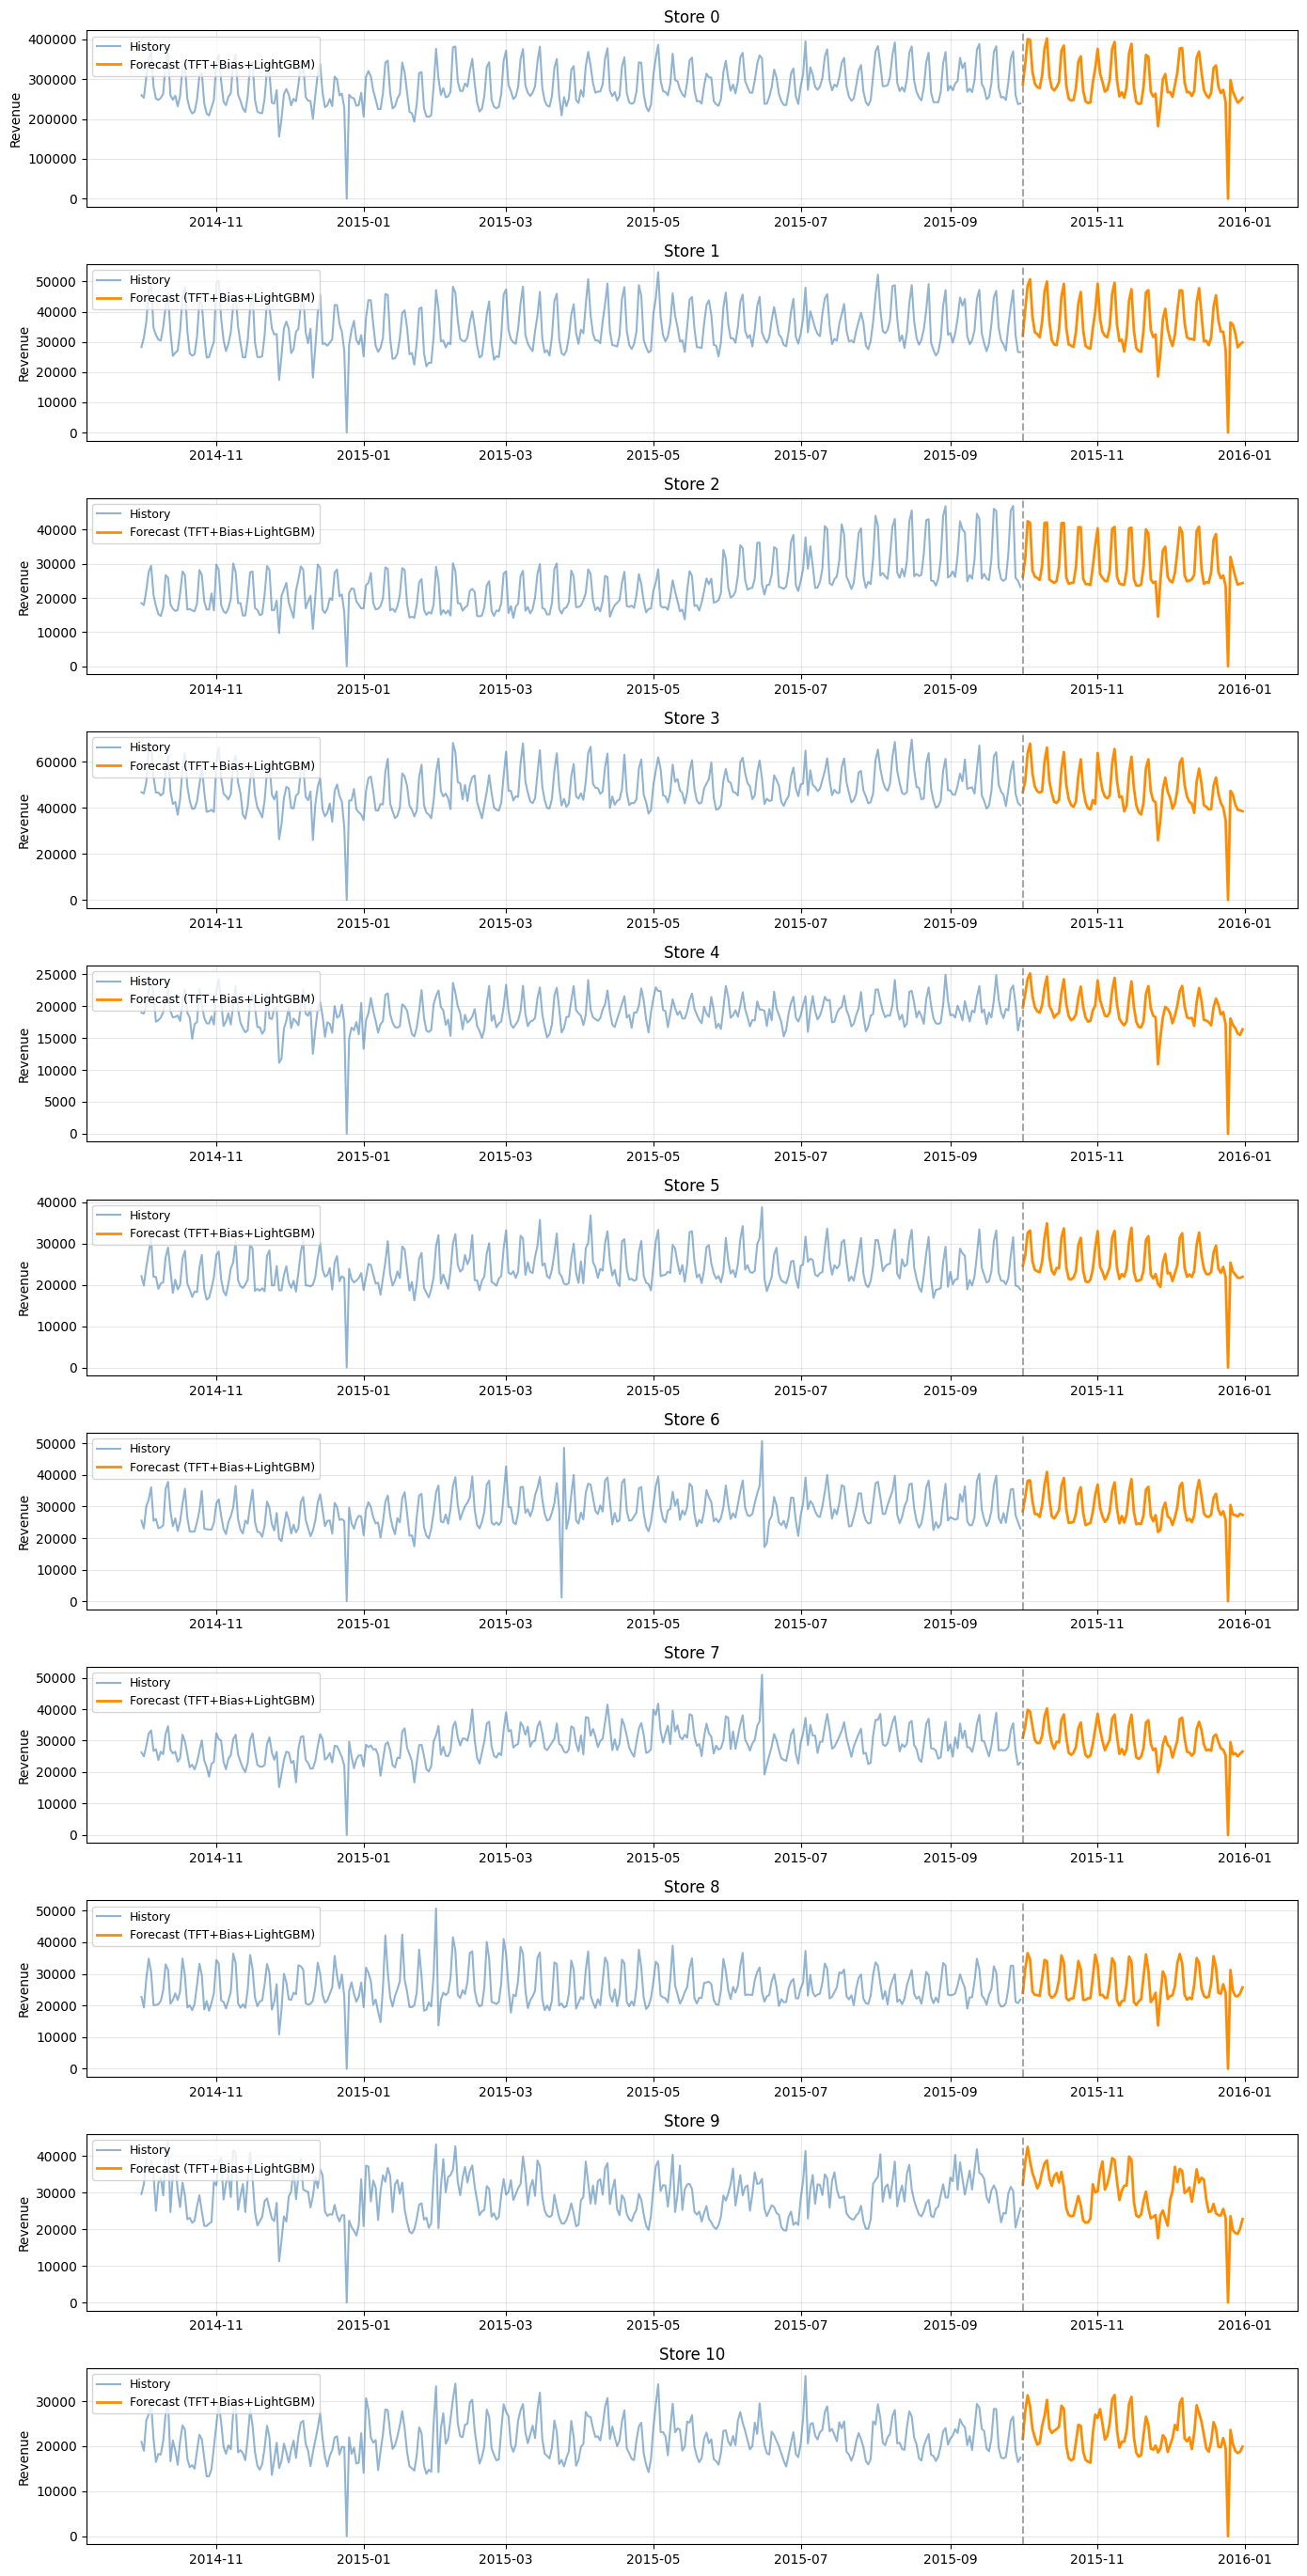

In [9]:
# Cell 8: Plot
RESULTS_DIR = 'Results'
os.makedirs(RESULTS_DIR, exist_ok=True)

store_ids_plot = ['0'] + [str(i) for i in range(1, 11)]
n = len(store_ids_plot)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=False)
if n == 1: axes = [axes]
history_window = pd.Timedelta(days=365)
for ax, s in zip(axes, store_ids_plot):
    hist = df[(df['store_id']==s)&(df['date']<FORECAST_START)&(df['date']>=FORECAST_START-history_window)]
    ax.plot(hist['date'], hist['revenue'], color='steelblue', alpha=0.6, label='History')
    pred = submission_final[submission_final['store_id']==s].sort_values('date')
    ax.plot(pred['date'], pred['prediction'], color='darkorange', linewidth=2, label='Forecast (TFT+Bias+LightGBM)')
    ax.axvline(FORECAST_START, linestyle='--', color='gray', alpha=0.7)
    ax.set_title(f'Store {s}')
    ax.set_ylabel('Revenue'); ax.grid(True, alpha=0.3); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR,'forecast_plots.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Export

In [10]:
# Cell 9: Export
submission_export.to_csv(os.path.join(RESULTS_DIR,'forecast_submission.csv'), index=False)
submission_final.to_csv(os.path.join(RESULTS_DIR,'forecast_predictions_long.csv'), index=False)
print('Done. (Exported LightGBM-corrected predictions)')

Done. (Exported LightGBM-corrected predictions)
